## Access Satellite Optical Water Type 1Day Noaa20 (Zarr)
This Jupyter notebook demonstrates how to access and plot satellite_optical_water_type_1day_noaa20 data, available as a [Zarr](https://zarr.dev/) dataset stored on S3.

🔗 More information about the dataset is available [in the AODN metadata catalogue](https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/5f359ca7-396a-4c1a-8388-77a50ad39859).

📌 The source of truth for this notebook is maintained on [GitHub](https://github.com/aodn/aodn_cloud_optimised/tree/main/notebooks/satellite_optical_water_type_1day_noaa20.ipynb).


In [1]:
dataset_name = "satellite_optical_water_type_1day_noaa20"

## Install/Update packages and Load common functions

In [2]:
import os, requests, importlib.util

open('setup.py', 'w').write(requests.get('https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py').text)

spec = importlib.util.spec_from_file_location("setup", "setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

setup.install_requirements()
setup.load_dataquery()

✅ Virtual environment already exists, skipping creation.


Using Python 3.11.6 environment at: /home/leonardo/git_repos/aodn_cloud_optimised/.venv
Resolved 204 packages in 641ms
Uninstalled 69 packages in 696ms
Installed 69 packages in 209ms
 - aiobotocore==3.7.0
 + aiobotocore==2.26.0
 - aiohappyeyeballs==2.7.1
 + aiohappyeyeballs==2.6.1
 - aiohttp==3.14.1
 + aiohttp==3.13.2
 - anyio==4.14.2
 + anyio==4.12.0
 - attrs==26.1.0
 + attrs==25.4.0
 - bokeh==3.9.1
 + bokeh==3.8.1
 - boto3==1.43.0
 + boto3==1.41.5
 - botocore==1.43.0
 + botocore==1.41.5
 - certifi==2026.6.17
 + certifi==2025.11.12
 - cffi==2.1.0
 + cffi==2.0.0
 - click==8.4.2
 + click==8.3.1
 - coiled==1.135.1
 + coiled==1.130.0
 - cryptography==49.0.0
 + cryptography==46.0.3
 - dask==2026.7.0
 + dask==2025.12.0
 - decorator==5.3.1
 + decorator==5.2.1
 - distributed==2026.7.0
 + distributed==2025.12.0
 - fabric==3.2.3
 + fabric==3.2.2
 - filelock==3.29.7
 + filelock==3.20.1
 - fsspec==2026.6.0
 + fsspec==2025.12.0
 - geopandas==1.1.4
 + geopandas==1.1.1
 - h5netcdf==1.8.1
 + h5netcdf

✅ Local version 0.3.28 is up to date (remote: 0.3.28)


In [3]:
from DataQuery import GetAodn

/home/leonardo/git_repos/aodn_cloud_optimised/notebooks/DataQuery.py:4826: UserWarning: registration of accessor <class 'DataQuery.AODNAccessor'> under name 'aodn' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  @pd.api.extensions.register_dataframe_accessor("aodn")


# Understanding the Dataset

In [4]:
# remote zarr dataset
aodn = GetAodn()
dname = f'{dataset_name}.zarr'
%time aodn_dataset = aodn.get_dataset(dname)

CPU times: user 1.67 s, sys: 140 ms, total: 1.81 s
Wall time: 2.87 s


In [5]:
ds = aodn_dataset.zarr_store
ds.info()

xarray.Dataset {
dimensions:
	time = 130 ;
	latitude = 9601 ;
	longitude = 13601 ;

variables:
	object filename(time) ;
	float64 latitude(latitude) ;
		latitude:axis = Y ;
		latitude:long_name = latitude ;
		latitude:standard_name = latitude ;
		latitude:units = degrees_north ;
	float64 longitude(longitude) ;
		longitude:axis = X ;
		longitude:long_name = longitude ;
		longitude:standard_name = longitude ;
		longitude:units = degrees_east ;
	float64 owtd_csiro(time, latitude, longitude) ;
		owtd_csiro:comment = CSIRO implementation of algorithm by Moore et al. (2009), RSE, 113, pp2424-2430, doi:10.1016/j.rse.2009.07.016 ;
		owtd_csiro:flag_applied = HISATZEN LAND CLDICE NAVFAIL HIGLINT ;
		owtd_csiro:long_name = Dominant optical water type ;
		owtd_csiro:units = dimensionless ;
		owtd_csiro:valid_max = 8 ;
		owtd_csiro:valid_min = 1 ;
	datetime64[ns] time(time) ;
		time:axis = T ;
		time:long_name = time ;
		time:standard_name = time ;

// global attributes:
	:Conventions = CF-1.6 ;
	:

## Plot time coverage

In [6]:
aodn_dataset.get_temporal_extent()

(Timestamp('2025-10-18 05:30:00'), Timestamp('2026-03-01 05:30:00'))

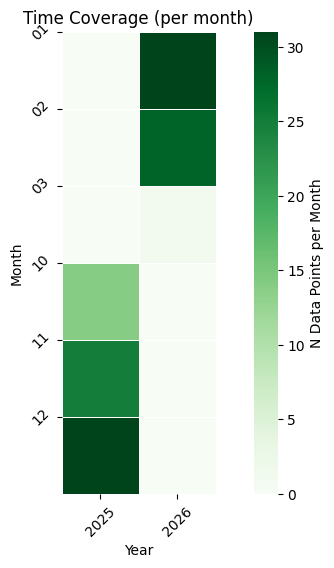

In [7]:
aodn_dataset.plot_time_coverage()

## Timeseries at a point

In [8]:
%%time
time_series_df = aodn_dataset.get_timeseries_data(var_name='owtd_csiro', 
                                                  lat=-48, 
                                                  lon=144, 
                                                  date_start='2025-11-01', 
                                                  date_end='2026-01-15', 
                                                  lon_name_override="longitude", 
                                                  lat_name_override="latitude")
time_series_df

CPU times: user 427 ms, sys: 126 ms, total: 553 ms
Wall time: 565 ms


## Plot a gridded variable

2026-08-12 14:36:04,123 - aodn.GetAodn - INFO - Plotting 'Dominant optical water type' for 6 time steps.
/home/leonardo/git_repos/aodn_cloud_optimised/notebooks/DataQuery.py:3913: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(
/home/leonardo/git_repos/aodn_cloud_optimised/.venv/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


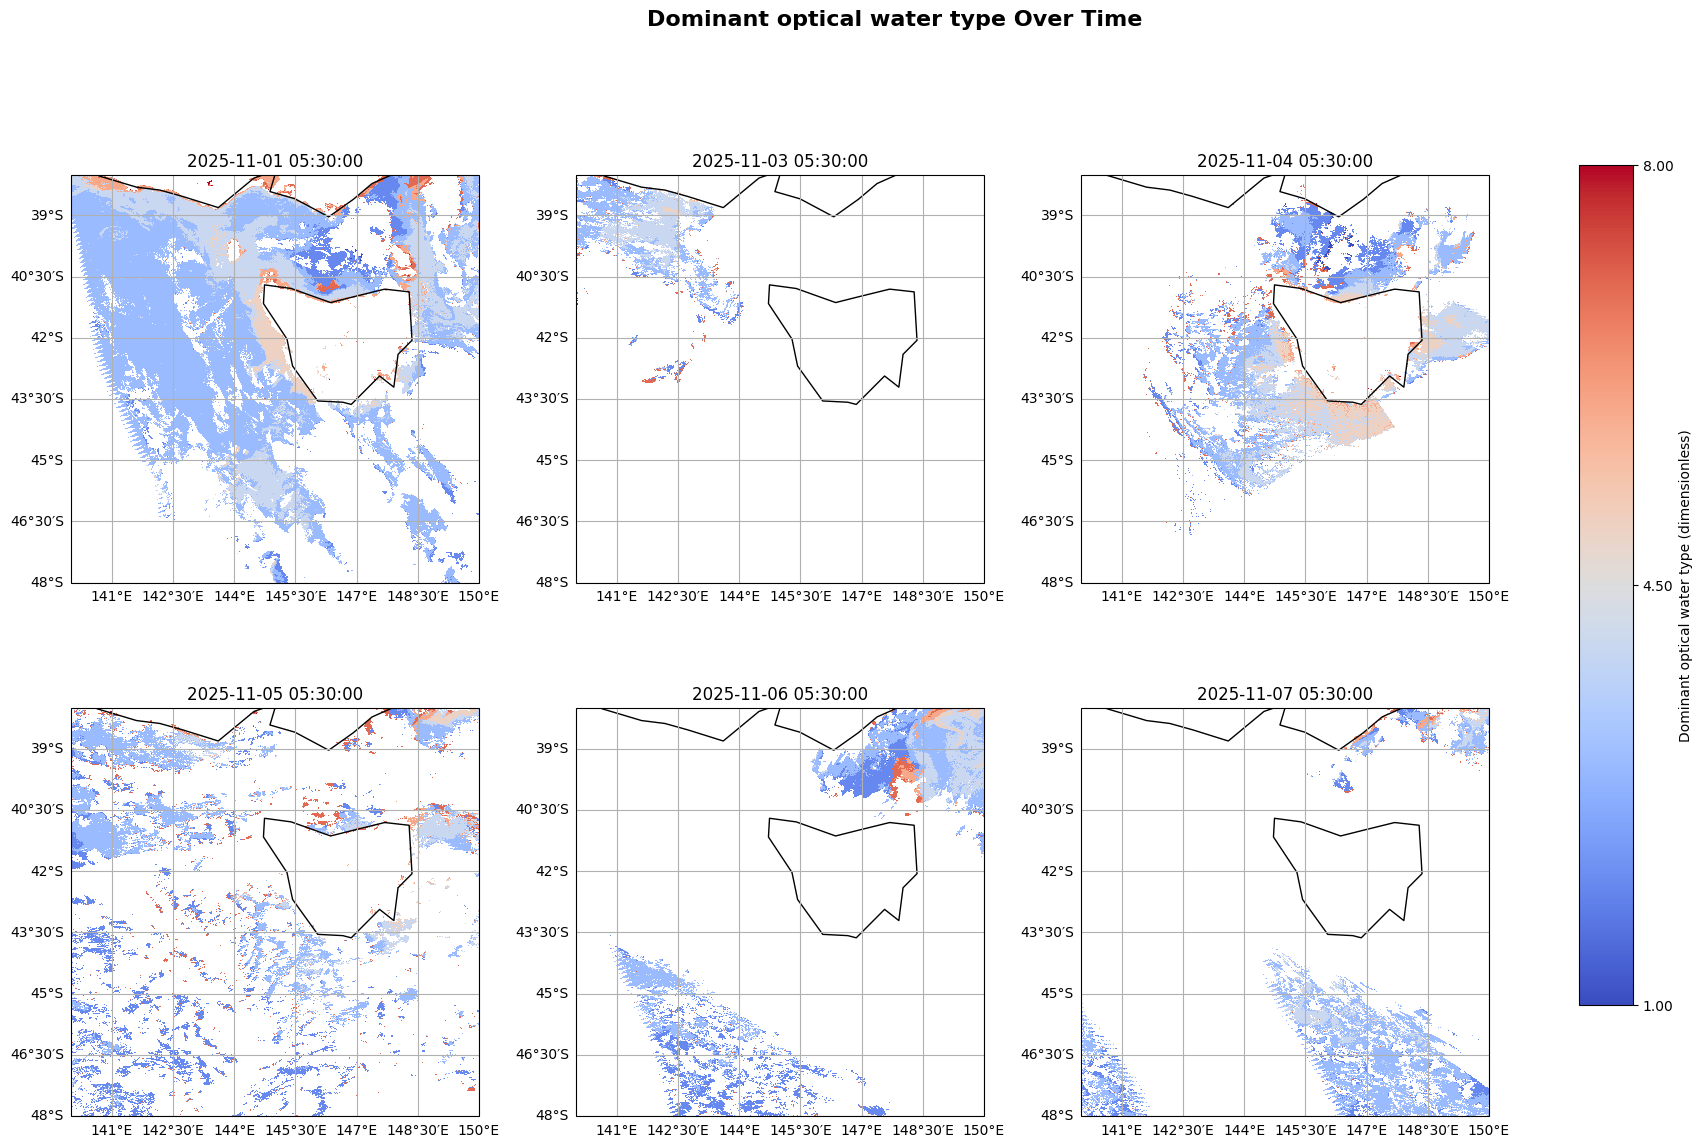

CPU times: user 13.5 s, sys: 4.97 s, total: 18.4 s
Wall time: 15 s


In [9]:
%%time
time_series_df = aodn_dataset.plot_gridded_variable(var_name='owtd_csiro', 
                                                    date_start='2025-11-01',                                                
                                                    lon_name_override="longitude", 
                                                    lat_name_override="latitude", 
                                                    lon_slice=(140, 150),
                                                    lat_slice=(-48, -38))